In [ ]:
## Markdown
# Geographic Distribution Analysis

## Objective
- Analyze SIP Amount by State.
- Compare T30 vs B30 City Tier distribution.

In [1]:
# Import Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
# Load Dataset
df = pd.read_csv("../data/processed/08_investor_transactions_clean.csv")

In [3]:
# Check Dataset
print(df.shape)

print(df.columns)

df.head()

(32778, 13)
Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


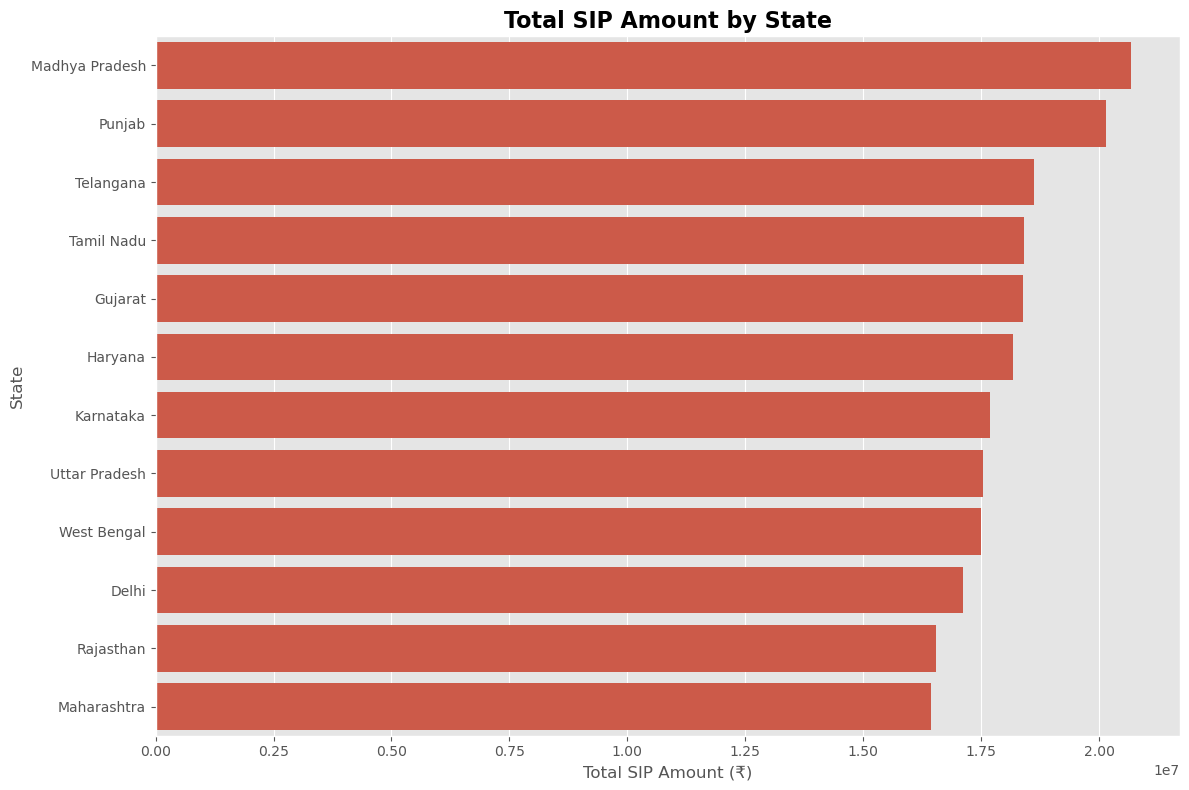

In [4]:
# Filter only SIP transactions
sip_df = df[df["transaction_type"] == "SIP"]

# Sum SIP amount by state
state_sip = (
    sip_df.groupby("state")["amount_inr"]
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(12,8))

sns.barplot(
    x=state_sip.values,
    y=state_sip.index
)

plt.title(
    "Total SIP Amount by State",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total SIP Amount (₹)")
plt.ylabel("State")

plt.tight_layout()

plt.savefig(
    "../reports/08_sip_by_state.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

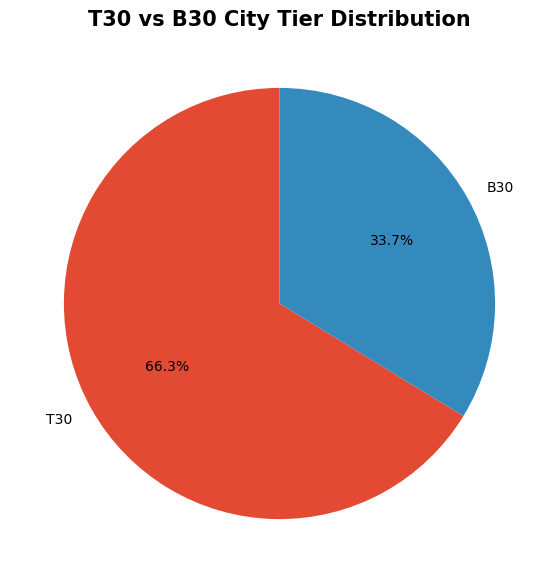

In [6]:
# T30 vs B30 Pie Chart
city_counts = df["city_tier"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    city_counts,
    labels=city_counts.index,
    autopct="%1.1f%%",
    startangle=90
)

plt.title(
    "T30 vs B30 City Tier Distribution",
    fontsize=15,
    fontweight="bold"
)

plt.savefig(
    "../reports/09_city_tier_distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()